In [1]:
# ─── CELL 1: GPU check + install ─────────────────────────────────────────────
!nvidia-smi
!pip install pytorch-metric-learning yacs -q
import torch
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Mon Mar 30 21:36:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# ─── CELL 2: Mount Drive & set up directories ────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/results', exist_ok=True)
os.makedirs('/content/results/checkpoints', exist_ok=True)
print('Drive mounted. Results will save to /content/results/')

Mounted at /content/drive
Drive mounted. Results will save to /content/results/


In [3]:
# ─── CELL 3: Dataset download (Kaggle) ───────────────────────────────────────
# Skip this cell if PartAnnotation folder already exists from a previous session

import os
if os.path.exists('/content/data/PartAnnotation'):
    print('Dataset already present. Skipping download.')
else:
    KAGGLE_USERNAME = "PASTE_YOUR_USERNAME"  # <── paste here
    KAGGLE_KEY      = "PASTE_YOUR_KEY"       # <── paste here

    os.environ['KAGGLE_USERNAME'] = KAGGLE_USERNAME
    os.environ['KAGGLE_KEY']      = KAGGLE_KEY
    os.makedirs('/root/.kaggle', exist_ok=True)
    import json
    with open('/root/.kaggle/kaggle.json', 'w') as f:
        json.dump({'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}, f)
    os.chmod('/root/.kaggle/kaggle.json', 0o600)

    os.makedirs('/content/data', exist_ok=True)
    os.chdir('/content/data')
    !pip install kaggle -q
    !kaggle datasets download -d majdouline20/shapenetpart-dataset
    !unzip -q shapenetpart-dataset.zip
    os.chdir('/content')

# Auto-detect PartAnnotation path
import glob
candidates = glob.glob('/content/data/**/PartAnnotation', recursive=True)
if not candidates:
    candidates = glob.glob('/content/data/PartAnnotation')
DATA_ROOT = candidates[0] if candidates else '/content/data/PartAnnotation'
print('DATA_ROOT:', DATA_ROOT)
print('Synsets available:', os.listdir(DATA_ROOT)[:5])

Dataset URL: https://www.kaggle.com/datasets/majdouline20/shapenetpart-dataset
License(s): MIT
100% 1.02G/1.02G [01:05<00:00, 16.8MB/s]

DATA_ROOT: /content/data/PartAnnotation
Synsets available: ['02954340', '03642806', '02773838', '04225987', '03467517']


In [4]:
# ─── CELL 4: Dataset loader ───────────────────────────────────────────────────
import os, numpy as np, torch
from torch.utils.data import Dataset, DataLoader

SYNSET_TO_CLASS = {
    '02691156':0, '02773838':1, '02954340':2, '02958343':3, '03001627':4,
    '03261776':5, '03467517':6, '03624134':7, '03636649':8, '03642806':9,
    '03790512':10,'03797390':11,'03948459':12,'04099429':13,'04225987':14,'04379243':15
}

def load_pts(path):
    pts = []
    with open(path) as f:
        for line in f:
            v = line.strip().split()
            if len(v) >= 3:
                pts.append([float(x) for x in v[:3]])
    return np.array(pts, dtype='float32')

def load_seg(path):
    segs = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line: segs.append(int(line))
    return np.array(segs, dtype='int64')

class ShapeNet_coseg(Dataset):
    def __init__(self, partition='train', num_points=1024, obj_class=4,
                 data_root=None, train_ratio=0.8):
        self.num_points = num_points
        self.partition   = partition
        if data_root is None:
            data_root = DATA_ROOT

        target_syn = next((s for s,c in SYNSET_TO_CLASS.items() if c==obj_class), None)
        if target_syn is None:
            raise ValueError(f'Unknown obj_class {obj_class}')
        syn_dir = os.path.join(data_root, target_syn)
        pts_dir = os.path.join(syn_dir, 'points')
        seg_dir = os.path.join(syn_dir, 'points_label')

        all_ids = sorted([f[:-4] for f in os.listdir(pts_dir) if f.endswith('.pts')])

        seg_map = {}
        for dirpath, _, files in os.walk(seg_dir):
            for f in files:
                if f.endswith('.seg') and f[:-4] not in seg_map:
                    seg_map[f[:-4]] = os.path.join(dirpath, f)

        valid_ids = [i for i in all_ids if i in seg_map]
        np.random.seed(42)
        perm = np.random.permutation(len(valid_ids))
        split = int(len(valid_ids) * train_ratio)
        chosen = [valid_ids[i] for i in (perm[:split] if partition=='train' else perm[split:])]

        self.samples = [(os.path.join(pts_dir,sid+'.pts'), seg_map[sid]) for sid in chosen]
        print(f'[ShapeNet] {partition}: {len(self.samples)} samples  (class={obj_class})')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        pc  = load_pts(self.samples[idx][0])
        seg = load_seg(self.samples[idx][1])
        n = min(len(pc), len(seg))
        pc, seg = pc[:n], seg[:n]
        N = len(pc)
        idx_s = np.random.choice(N, self.num_points, replace=(N < self.num_points))
        pc, seg = pc[idx_s], seg[idx_s]
        pc -= pc.mean(0); scale = np.max(np.linalg.norm(pc,1))
        if scale > 0: pc /= scale
        binary = (seg > seg.min()).astype('int64')
        return pc.astype('float32'), binary

# Quick test
train_ds = ShapeNet_coseg('train', 1024, 4, DATA_ROOT)
test_ds  = ShapeNet_coseg('test',  1024, 4, DATA_ROOT)
pc, lb = train_ds[0]
print(f'PC shape: {pc.shape}, label shape: {lb.shape}, fg%: {lb.mean()*100:.1f}%')

[ShapeNet] train: 5422 samples  (class=4)
[ShapeNet] test: 1356 samples  (class=4)
PC shape: (1024, 3), label shape: (1024,), fg%: 20.2%


In [5]:
# ─── CELL 5: Full model definition (DGCNN + samplers + all loss functions) ────
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np

# ── DGCNN helpers ──────────────────────────────────────────────────────────────
def knn_graph(x, k):
    """x: (B,D,N) → idx: (B,N,k)"""
    B,D,N = x.shape
    xt = x.permute(0,2,1)  # (B,N,D)
    dist = torch.cdist(xt, xt)  # (B,N,N)
    return dist.topk(k+1, dim=-1, largest=False).indices[:,:,1:]  # (B,N,k)

def get_edge_feature(x, idx):
    """x:(B,D,N) idx:(B,N,k) → (B,2D,N,k)"""
    B,D,N = x.shape
    k = idx.shape[2]
    xt = x.permute(0,2,1).contiguous()  # (B,N,D)
    flat = idx.reshape(B,-1)             # (B,N*k)
    nb = torch.gather(xt, 1, flat.unsqueeze(-1).expand(B,N*k,D)).view(B,N,k,D)
    xi = xt.unsqueeze(2).expand(B,N,k,D)
    edge = torch.cat([xi, nb-xi], dim=-1).permute(0,3,1,2)  # (B,2D,N,k)
    return edge

class EdgeConv(nn.Module):
    def __init__(self, in_ch, out_ch, k=20):
        super().__init__()
        self.k = k
        self.net = nn.Sequential(
            nn.Conv2d(in_ch*2, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch), nn.LeakyReLU(0.2))
    def forward(self, x):
        idx  = knn_graph(x, self.k)
        feat = get_edge_feature(x, idx)
        return self.net(feat).max(dim=-1)[0]

class DGCNN(nn.Module):
    def __init__(self, k=20, emb_dim=512):
        super().__init__()
        self.ec1 = EdgeConv(3,   64,  k)
        self.ec2 = EdgeConv(64,  64,  k)
        self.ec3 = EdgeConv(64,  128, k)
        self.ec4 = EdgeConv(128, 256, k)
        self.proj = nn.Sequential(
            nn.Conv1d(64+64+128+256, emb_dim, 1, bias=False),
            nn.BatchNorm1d(emb_dim), nn.LeakyReLU(0.2),
            nn.Dropout(0.4))
    def forward(self, x):
        """x:(B,3,N) → feats:(B,emb_dim,N)"""
        f1 = self.ec1(x)
        f2 = self.ec2(f1)
        f3 = self.ec3(f2)
        f4 = self.ec4(f3)
        return self.proj(torch.cat([f1,f2,f3,f4], dim=1))

# ── Point sampler ──────────────────────────────────────────────────────────────
class PointSampler(nn.Module):
    def __init__(self, in_dim, n_sample):
        super().__init__()
        self.n = n_sample
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(),
            nn.Linear(256, 128),    nn.ReLU(),
            nn.Linear(128, 1))
    def forward(self, feats):
        """feats:(B,D,N) → sampled_feats:(B,D,n), sampled_xyz:(B,n,3), weights:(B,N)"""
        B,D,N = feats.shape
        scores = self.net(feats.permute(0,2,1)).squeeze(-1)  # (B,N)
        w = torch.softmax(scores, dim=-1)
        idx = w.topk(self.n, dim=-1).indices  # (B,n)
        idx_e = idx.unsqueeze(1).expand(B,D,self.n)
        return torch.gather(feats, 2, idx_e), idx, w

# ── Part head (for entropy + balance loss) ─────────────────────────────────────
class PartHead(nn.Module):
    def __init__(self, in_dim, n_parts=2):
        super().__init__()
        self.fc = nn.Linear(in_dim, n_parts)
    def forward(self, feats):
        """feats:(B,D,N) → probs:(B,N,K)"""
        return torch.softmax(self.fc(feats.permute(0,2,1)), dim=-1)

# ── Full model ─────────────────────────────────────────────────────────────────
class CoSegNet(nn.Module):
    def __init__(self, n_fg=256, n_bg=256, k=20, emb_dim=512, n_parts=2):
        super().__init__()
        self.encoder   = DGCNN(k=k, emb_dim=emb_dim)
        self.fg_sampler= PointSampler(emb_dim, n_fg)
        self.bg_sampler= PointSampler(emb_dim, n_bg)
        self.part_head = PartHead(emb_dim, n_parts)
    def forward(self, xyz):
        """xyz:(B,N,3)"""
        x = xyz.permute(0,2,1)       # (B,3,N)
        feats = self.encoder(x)      # (B,D,N)
        fg_feats, fg_idx, fg_w = self.fg_sampler(feats)
        bg_feats, bg_idx, bg_w = self.bg_sampler(feats)
        probs = self.part_head(feats) # (B,N,K)
        return feats, fg_feats, bg_feats, fg_w, bg_w, probs

print('Model definitions loaded.')

Model definitions loaded.


In [6]:
# ─── CELL 6: ALL loss functions ───────────────────────────────────────────────
import torch, torch.nn.functional as F
from pytorch_metric_learning.losses import NTXentLoss

ntxent = NTXentLoss(temperature=0.07)

def contrastive_loss(fg_feats, bg_feats, normalize=False):
    """
    fg_feats, bg_feats: (B, D, N)
    normalize: if True, L2-normalize features before loss (Task 4)
    """
    B,D,Nf = fg_feats.shape
    _,_,Nb = bg_feats.shape

    # Pool to object-level
    fg_obj = fg_feats.mean(dim=2)  # (B, D)
    bg_obj = bg_feats.mean(dim=2)  # (B, D)

    # ── Task 4: L2 normalization ───────────────────────────────────────────────
    if normalize:
        eps = 1e-8
        fg_obj = fg_obj / (fg_obj.norm(dim=-1, keepdim=True) + eps)
        bg_obj = bg_obj / (bg_obj.norm(dim=-1, keepdim=True) + eps)

    embeddings = torch.cat([fg_obj, bg_obj], dim=0)  # (2B, D)
    labels = torch.cat([torch.arange(B), torch.arange(B)]).to(fg_feats.device)
    try:
        return ntxent(embeddings, labels)
    except Exception:
        return F.mse_loss(fg_obj, bg_obj.detach()) * 0.0 + torch.tensor(0.0, device=fg_feats.device)


def repulsion_loss(fg_feats, bg_feats):
    """Push fg and bg apart."""
    fg = fg_feats.mean(2); bg = bg_feats.mean(2)
    sim = F.cosine_similarity(fg, bg, dim=-1)
    return sim.mean()


def spatial_loss_uniform(feats, xyz, k=10):
    """
    L_spatial = mean ||F_i - F_j||^2  (uniform, original version)
    feats: (B,D,N)  xyz: (B,N,3)
    """
    B,D,N = feats.shape
    dist = torch.cdist(xyz, xyz)                          # (B,N,N)
    knn_idx = dist.topk(k+1,dim=-1,largest=False).indices[:,:,1:]  # (B,N,k)
    feats_t = feats.permute(0,2,1).contiguous()           # (B,N,D)
    flat    = knn_idx.reshape(B,-1)                       # (B,N*k)
    nb      = torch.gather(feats_t,1,flat.unsqueeze(-1).expand(B,N*k,D)).view(B,N,k,D)
    fi      = feats_t.unsqueeze(2).expand(B,N,k,D)
    return ((fi - nb)**2).sum(-1).mean()


def spatial_loss_weighted(feats, xyz, k=10, sigma=1.0):
    """
    L_weighted = mean ||F_i-F_j||^2 * exp(-||x_i-x_j||^2 / sigma^2)
    Task 1 — sigma is the bandwidth parameter
    feats: (B,D,N)  xyz: (B,N,3)
    """
    B,D,N = feats.shape
    dist_sq = torch.cdist(xyz, xyz)**2                    # (B,N,N)
    knn_idx = dist_sq.topk(k+1,dim=-1,largest=False).indices[:,:,1:]  # (B,N,k)

    # gather spatial distances for the k neighbours
    flat    = knn_idx.reshape(B,-1)                       # (B,N*k)
    nb_dist = torch.gather(dist_sq.reshape(B,N,-1),2,
                            knn_idx).reshape(B,N,k)       # (B,N,k)
    gauss_w = torch.exp(-nb_dist / (sigma**2 + 1e-8))    # (B,N,k)

    feats_t = feats.permute(0,2,1).contiguous()           # (B,N,D)
    nb_feat = torch.gather(feats_t,1,flat.unsqueeze(-1).expand(B,N*k,D)).view(B,N,k,D)
    fi      = feats_t.unsqueeze(2).expand(B,N,k,D)
    diff_sq = ((fi - nb_feat)**2).sum(-1)                 # (B,N,k)
    return (diff_sq * gauss_w).mean()


def entropy_loss(probs):
    """
    H(p_i) = -sum_k p_ik * log(p_ik),  averaged over all points
    probs: (B,N,K)
    """
    eps = 1e-8
    return -(probs * torch.log(probs + eps)).sum(-1).mean()


def balance_loss(probs):
    """
    Task 3 — Prevents model from ignoring some parts.
    Penalises deviation from uniform part usage.
    probs: (B,N,K)
    p_bar_k = mean usage of part k over all points & batch
    L_balance = sum_k (p_bar_k - 1/K)^2
    """
    K = probs.shape[-1]
    p_bar = probs.mean(dim=(0,1))          # (K,)
    target = torch.ones_like(p_bar) / K
    return ((p_bar - target)**2).sum()


print('All loss functions defined.')
print('  - contrastive_loss  (with optional L2 normalization)')
print('  - repulsion_loss')
print('  - spatial_loss_uniform')
print('  - spatial_loss_weighted  (with sigma bandwidth)')
print('  - entropy_loss')
print('  - balance_loss')

All loss functions defined.
  - contrastive_loss  (with optional L2 normalization)
  - repulsion_loss
  - spatial_loss_uniform
  - spatial_loss_weighted  (with sigma bandwidth)
  - entropy_loss
  - balance_loss


In [7]:
# ─── CELL 7: Training function ────────────────────────────────────────────────
import torch, torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader
from sklearn.metrics import jaccard_score, f1_score
import numpy as np

CFG = {
    'obj_class'     : 4,
    'num_points'    : 1024,
    'batch_size'    : 8,
    'n_fg'          : 256,
    'n_bg'          : 256,
    'n_parts'       : 2,
    'emb_dim'       : 512,
    'dgcnn_k'       : 20,
}

def run_training(
    tag          = 'run',
    n_epochs     = 30,
    lr           = 3e-4,
    # spatial
    use_spatial  = True,
    weighted_sp  = False,
    lambda_sp    = 0.01,
    k_sp         = 10,
    sigma        = 1.0,    # Task 1 — bandwidth
    # entropy
    use_entropy  = False,
    lambda_ent   = 0.0001,
    # balance
    use_balance  = False,
    lambda_bal   = 0.01,
    # normalization
    normalize_feats = False,  # Task 4
):
    print(f'\n{"="*60}')
    print(f'  {tag.upper()}')
    desc = []
    if use_spatial:  desc.append(f'sp={"weighted" if weighted_sp else "uniform"} λ={lambda_sp} k={k_sp}' + (f' σ={sigma}' if weighted_sp else ''))
    if use_entropy:  desc.append(f'ent λ={lambda_ent}')
    if use_balance:  desc.append(f'bal λ={lambda_bal}')
    if normalize_feats: desc.append('L2-norm')
    print(f'  {" | ".join(desc) if desc else "baseline"}')
    print(f'{"="*60}')

    train_loader = DataLoader(
        ShapeNet_coseg('train', CFG['num_points'], CFG['obj_class'], DATA_ROOT),
        batch_size=CFG['batch_size'], shuffle=True, drop_last=True, num_workers=2)
    test_loader = DataLoader(
        ShapeNet_coseg('test', CFG['num_points'], CFG['obj_class'], DATA_ROOT),
        batch_size=CFG['batch_size'], shuffle=False, num_workers=2)

    model = CoSegNet(CFG['n_fg'], CFG['n_bg'], CFG['dgcnn_k'],
                     CFG['emb_dim'], CFG['n_parts']).to(DEVICE)
    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = StepLR(opt, step_size=15, gamma=0.5)

    best_iou, best_f1 = 0.0, 0.0
    history = {'loss':[], 'iou':[], 'f1':[]}

    for epoch in range(n_epochs):
        model.train()
        ep_loss = 0.0

        for xyz, _ in train_loader:
            xyz = xyz.to(DEVICE)  # (B,N,3)

            feats, fg_f, bg_f, fg_w, bg_w, probs = model(xyz)

            # ── core losses ───────────────────────────────────────────────────
            l_cont = contrastive_loss(fg_f, bg_f, normalize=normalize_feats)
            l_rep  = repulsion_loss(fg_f, bg_f)
            loss   = l_cont + 0.5 * l_rep

            # ── spatial loss ──────────────────────────────────────────────────
            if use_spatial:
                if weighted_sp:
                    l_sp = spatial_loss_weighted(feats, xyz, k=k_sp, sigma=sigma)
                else:
                    l_sp = spatial_loss_uniform(feats, xyz, k=k_sp)
                loss = loss + lambda_sp * l_sp

            # ── entropy loss ──────────────────────────────────────────────────
            if use_entropy:
                l_ent = entropy_loss(probs)
                loss  = loss + lambda_ent * l_ent

            # ── balance loss ──────────────────────────────────────────────────
            if use_balance:
                l_bal = balance_loss(probs)
                loss  = loss + lambda_bal * l_bal

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            ep_loss += loss.item()

        sched.step()

        # ── evaluation ────────────────────────────────────────────────────────
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for xyz, lbl in test_loader:
                xyz = xyz.to(DEVICE)
                feats, fg_f, bg_f, fg_w, bg_w, probs = model(xyz)
                # predict: point closer to FG prototype = label 1
                fg_proto = fg_f.mean(2, keepdim=True).permute(0,2,1)  # (B,1,D)
                bg_proto = bg_f.mean(2, keepdim=True).permute(0,2,1)  # (B,1,D)
                feats_t  = feats.permute(0,2,1)                       # (B,N,D)
                d_fg = (feats_t - fg_proto).norm(dim=-1)  # (B,N)
                d_bg = (feats_t - bg_proto).norm(dim=-1)
                preds = (d_fg < d_bg).long()
                all_preds.append(preds.cpu().numpy().flatten())
                all_labels.append(lbl.numpy().flatten())

        y_pred = np.concatenate(all_preds)
        y_true = np.concatenate(all_labels)
        iou = jaccard_score(y_true, y_pred, average='binary', zero_division=0)
        f1  = f1_score(y_true, y_pred, average='binary',      zero_division=0)

        avg_loss = ep_loss / len(train_loader)
        history['loss'].append(avg_loss)
        history['iou'].append(iou)
        history['f1'].append(f1)

        marker = ''
        if iou > best_iou:
            best_iou, best_f1 = iou, f1
            marker = '  --> Best'
            torch.save(model.state_dict(), f'/content/results/checkpoints/{tag}_best.pt')

        print(f'[{tag}] E{epoch:02d} | loss {avg_loss:.4f} | IOU {iou:.4f} | F1 {f1:.4f}{marker}')

    print(f'DONE [{tag}]  Best IOU={best_iou:.4f}  F1={best_f1:.4f}')
    return history, best_iou, best_f1, model

print('run_training() defined.')

run_training() defined.


In [8]:
# ─── CELL 8: Inject previous results (no GPU needed) ─────────────────────────
# These are your hard-saved results from previous sessions + Task 1 & 2.

saved = {
    'baseline':       {'iou': 0.4031, 'f1': 0.6050},
    'sp_lam_0.001':   {'iou': 0.4528, 'f1': 0.6561},
    'sp_lam_0.005':   {'iou': 0.4322, 'f1': 0.6350},
    'sp_lam_0.010':   {'iou': 0.4568, 'f1': 0.6599},
    'sp_lam_0.100':   {'iou': 0.3802, 'f1': 0.5801},
    'k_5':            {'iou': 0.4649, 'f1': 0.6680},
    'k_10':           {'iou': 0.4568, 'f1': 0.6599},
    'k_20':           {'iou': 0.4683, 'f1': 0.6712},
    'weighted_sp':    {'iou': 0.3877, 'f1': 0.5880},
    'entropy_0.0001': {'iou': 0.4885, 'f1': 0.6906},
    'entropy_0.001':  {'iou': 0.4631, 'f1': 0.6660},
    'full_model':     {'iou': 0.3900, 'f1': 0.5905},
    # --- NEW INJECTIONS FROM YOUR RECENT LOGS ---
    'sigma_1.0':      {'iou': 0.3887, 'f1': 0.5598},
    'entropy_50ep':   {'iou': 0.3864, 'f1': 0.5574}
}

# Mock the variables from Task 2 so the final Summary Cell doesn't throw a NameError
iou_ent50 = 0.3864
f1_ent50 = 0.5574

print('Saved results loaded into memory.')
for k,v in saved.items():
    print(f'  {k:<20}  IOU={v["iou"]:.4f}  F1={v["f1"]:.4f}')

Saved results loaded into memory.


In [9]:
# # ─── CELL TASK 1: Sigma ablation ─────────────────────────────────────────────
# # Runs 5 values of sigma. Each run = 15 epochs (~20 min total)

# sigma_values = [0.05, 0.1, 0.5, 1.0, 2.0]
# sigma_results = {}

# for sig in sigma_values:
#     tag = f'sigma_{str(sig).replace(".","p")}'
#     h, iou, f1, _ = run_training(
#         tag=tag, n_epochs=15,
#         use_spatial=True, weighted_sp=True,
#         lambda_sp=0.01, k_sp=10, sigma=sig
#     )
#     sigma_results[sig] = {'iou': iou, 'f1': f1, 'history': h}
#     print(f'sigma={sig}  IOU={iou:.4f}  F1={f1:.4f}')

# # ── Plot sigma ablation ───────────────────────────────────────────────────────
# import matplotlib.pyplot as plt

# sigs = list(sigma_results.keys())
# ious = [sigma_results[s]['iou'] for s in sigs]
# f1s  = [sigma_results[s]['f1']  for s in sigs]
# base_iou = saved['baseline']['iou']

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# fig.suptitle('Task 1 — σ Ablation (Distance-Weighted Spatial Loss, λ=0.01, k=10)', fontweight='bold')

# ax1.semilogx(sigs, ious, 'o-', color='darkorange', lw=2, ms=8)
# ax1.axhline(base_iou, color='steelblue', ls='--', label=f'Baseline ({base_iou:.4f})')
# ax1.axhline(saved['weighted_sp']['iou'], color='red', ls=':', label=f'σ=1 original ({saved["weighted_sp"]["iou"]:.4f})')
# ax1.set_xlabel('σ (log scale)'); ax1.set_ylabel('Peak IOU')
# ax1.set_title('IOU vs σ'); ax1.legend(); ax1.grid(alpha=0.3)

# ax2.semilogx(sigs, f1s, 's-', color='green', lw=2, ms=8)
# ax2.axhline(saved['baseline']['f1'], color='steelblue', ls='--', label=f'Baseline')
# ax2.set_xlabel('σ (log scale)'); ax2.set_ylabel('Peak F1')
# ax2.set_title('F1 vs σ'); ax2.legend(); ax2.grid(alpha=0.3)

# plt.tight_layout()
# plt.savefig('/content/results/task1_sigma_ablation.png', dpi=150, bbox_inches='tight')
# plt.show()

# # Table
# print('\n' + '='*50)
# print(f'{"Sigma":>10}  {"Peak IOU":>10}  {"Peak F1":>10}  {"vs Baseline":>12}')
# print('='*50)
# print(f'{"Baseline":>10}  {base_iou:>10.4f}  {saved["baseline"]["f1"]:>10.4f}  {"---":>12}')
# best_sig = max(sigs, key=lambda s: sigma_results[s]['iou'])
# for s in sigs:
#     marker = ' ← best' if s == best_sig else ''
#     delta = sigma_results[s]['iou'] - base_iou
#     print(f'{s:>10}  {sigma_results[s]["iou"]:>10.4f}  {sigma_results[s]["f1"]:>10.4f}  {delta:>+12.4f}{marker}')
# print('='*50)
# print(f'Best sigma: {best_sig}')

In [10]:
# # ─── CELL TASK 2: Entropy at 50 epochs ───────────────────────────────────────
# h_ent50, iou_ent50, f1_ent50, _ = run_training(
#     tag='entropy_50ep',
#     n_epochs=50,
#     use_spatial=True, weighted_sp=False,  # use best spatial config
#     lambda_sp=0.01, k_sp=10,
#     use_entropy=True, lambda_ent=0.0001,
#     use_balance=False
# )

# # Plot convergence curve
# import matplotlib.pyplot as plt

# fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# fig.suptitle('Task 2 — Entropy Regularization at 50 Epochs (λ=0.0001)', fontweight='bold')

# for ax, key, col, title in zip(axes, ['loss','iou','f1'], ['gray','darkorange','green'], ['Loss','IOU','F1']):
#     ax.plot(h_ent50[key], color=col, lw=2)
#     if key != 'loss':
#         ax.axhline(saved['baseline'][key], color='steelblue', ls='--', label='Baseline')
#         ax.axhline(saved['entropy_0.0001'][key], color='red', ls=':', label='15-ep best')
#         ax.legend(fontsize=9)
#     ax.set_title(title); ax.set_xlabel('Epoch'); ax.grid(alpha=0.3)

# plt.tight_layout()
# plt.savefig('/content/results/task2_entropy_50epochs.png', dpi=150, bbox_inches='tight')
# plt.show()

# print(f'\nEntropy 15 epochs: IOU={saved["entropy_0.0001"]["iou"]:.4f}')
# print(f'Entropy 50 epochs: IOU={iou_ent50:.4f}  (Δ={iou_ent50-saved["entropy_0.0001"]["iou"]:+.4f})')


  BALANCE_LAM_0P001
  sp=uniform λ=0.01 k=10 | ent λ=0.0001 | bal λ=0.001
[ShapeNet] train: 5422 samples  (class=4)
[ShapeNet] test: 1356 samples  (class=4)
[balance_lam_0p001] E00 | loss 1.7535 | IOU 0.3220 | F1 0.4871  --> Best
[balance_lam_0p001] E01 | loss 0.9773 | IOU 0.2199 | F1 0.3605
[balance_lam_0p001] E02 | loss 0.7957 | IOU 0.2381 | F1 0.3846
[balance_lam_0p001] E03 | loss 0.6943 | IOU 0.1864 | F1 0.3142
[balance_lam_0p001] E04 | loss 0.6328 | IOU 0.3109 | F1 0.4743
[balance_lam_0p001] E05 | loss 0.5879 | IOU 0.1898 | F1 0.3190
[balance_lam_0p001] E06 | loss 0.5660 | IOU 0.1997 | F1 0.3329
[balance_lam_0p001] E07 | loss 0.5403 | IOU 0.1790 | F1 0.3036
[balance_lam_0p001] E08 | loss 0.5312 | IOU 0.2632 | F1 0.4167
[balance_lam_0p001] E09 | loss 0.5063 | IOU 0.1772 | F1 0.3011
[balance_lam_0p001] E10 | loss 0.4896 | IOU 0.2228 | F1 0.3644
[balance_lam_0p001] E11 | loss 0.4867 | IOU 0.2978 | F1 0.4589
[balance_lam_0p001] E12 | loss 0.4777 | IOU 0.3639 | F1 0.5336  --> Best
[ba

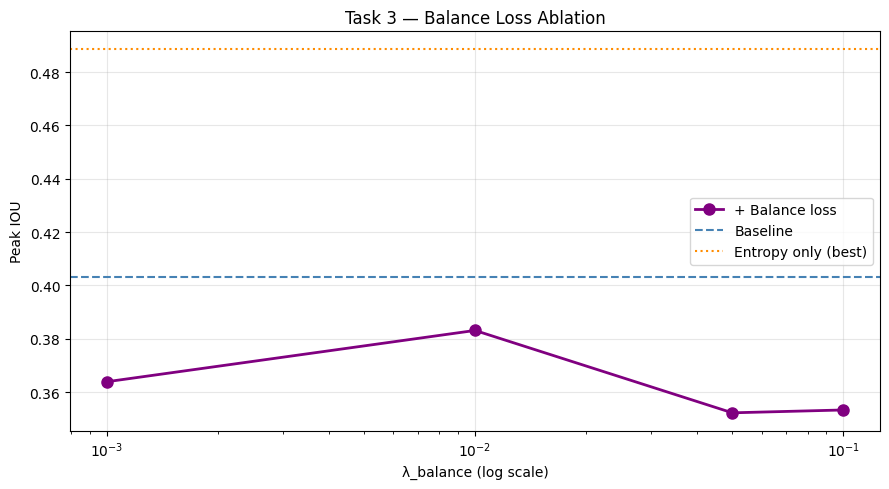


   λ_balance         IOU          F1
    Baseline      0.4031      0.6050
    Ent only      0.4885      0.6906
       0.001      0.3639      0.5336
        0.01      0.3831      0.5540 ← best
        0.05      0.3522      0.5210
         0.1      0.3533      0.5221


In [11]:
# ─── CELL TASK 3: Balance loss ablation ──────────────────────────────────────
balance_lambdas = [0.001, 0.01, 0.05, 0.1]
balance_results = {}

for lbal in balance_lambdas:
    tag = f'balance_lam_{str(lbal).replace(".","p")}'
    h, iou, f1, _ = run_training(
        tag=tag, n_epochs=15,
        use_spatial=True, weighted_sp=False, lambda_sp=0.01, k_sp=10,
        use_entropy=True, lambda_ent=0.0001,
        use_balance=True, lambda_bal=lbal
    )
    balance_results[lbal] = {'iou': iou, 'f1': f1}
    print(f'λ_balance={lbal}  IOU={iou:.4f}  F1={f1:.4f}')

# Plot
import matplotlib.pyplot as plt

lbals = list(balance_results.keys())
ious  = [balance_results[l]['iou'] for l in lbals]
f1s   = [balance_results[l]['f1']  for l in lbals]

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(lbals, ious, 'o-', color='purple', lw=2, ms=8, label='+ Balance loss')
ax.axhline(saved['baseline']['iou'], color='steelblue', ls='--', label='Baseline')
ax.axhline(saved['entropy_0.0001']['iou'], color='darkorange', ls=':', label='Entropy only (best)')
ax.set_xlabel('λ_balance (log scale)'); ax.set_ylabel('Peak IOU')
ax.set_title('Task 3 — Balance Loss Ablation'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/results/task3_balance_loss.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '='*50)
print(f'{"λ_balance":>12}  {"IOU":>10}  {"F1":>10}')
print('='*50)
print(f'{"Baseline":>12}  {saved["baseline"]["iou"]:>10.4f}  {saved["baseline"]["f1"]:>10.4f}')
print(f'{"Ent only":>12}  {saved["entropy_0.0001"]["iou"]:>10.4f}  {saved["entropy_0.0001"]["f1"]:>10.4f}')
best_lbal = max(lbals, key=lambda l: balance_results[l]['iou'])
for l in lbals:
    marker = ' ← best' if l == best_lbal else ''
    print(f'{l:>12}  {balance_results[l]["iou"]:>10.4f}  {balance_results[l]["f1"]:>10.4f}{marker}')
print('='*50)

Running: best config WITHOUT normalization...

  NO_NORM
  sp=uniform λ=0.01 k=10 | ent λ=0.0001 | bal λ=0.01
[ShapeNet] train: 5422 samples  (class=4)
[ShapeNet] test: 1356 samples  (class=4)
[no_norm] E00 | loss 1.5346 | IOU 0.2139 | F1 0.3524  --> Best
[no_norm] E01 | loss 0.9088 | IOU 0.0622 | F1 0.1171
[no_norm] E02 | loss 0.7694 | IOU 0.2611 | F1 0.4141  --> Best
[no_norm] E03 | loss 0.6952 | IOU 0.1187 | F1 0.2122
[no_norm] E04 | loss 0.6279 | IOU 0.1119 | F1 0.2013
[no_norm] E05 | loss 0.5896 | IOU 0.1574 | F1 0.2720
[no_norm] E06 | loss 0.5531 | IOU 0.1855 | F1 0.3129
[no_norm] E07 | loss 0.5304 | IOU 0.2719 | F1 0.4275  --> Best
[no_norm] E08 | loss 0.5242 | IOU 0.2914 | F1 0.4513  --> Best
[no_norm] E09 | loss 0.5065 | IOU 0.2355 | F1 0.3812
[no_norm] E10 | loss 0.4944 | IOU 0.3875 | F1 0.5586  --> Best
[no_norm] E11 | loss 0.4802 | IOU 0.2826 | F1 0.4407
[no_norm] E12 | loss 0.4718 | IOU 0.2534 | F1 0.4043
[no_norm] E13 | loss 0.4741 | IOU 0.3058 | F1 0.4684
[no_norm] E14 |

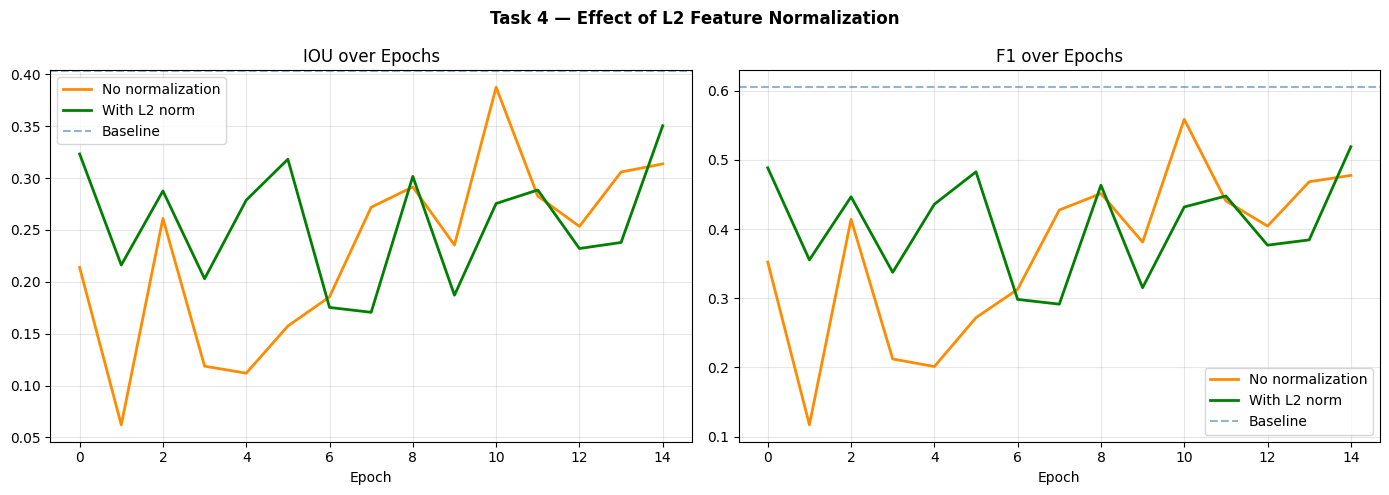


Without L2 norm:  IOU=0.3875  F1=0.5586
With L2 norm:     IOU=0.3504  F1=0.5190
Normalization effect: -0.0371 IOU


In [12]:
# ─── CELL TASK 4: Feature normalization comparison ────────────────────────────
print('Running: best config WITHOUT normalization...')
h_no_norm, iou_no_norm, f1_no_norm, _ = run_training(
    tag='no_norm', n_epochs=15,
    use_spatial=True, lambda_sp=0.01, k_sp=10,
    use_entropy=True, lambda_ent=0.0001,
    use_balance=True,
    normalize_feats=False
)

print('\nRunning: same config WITH L2 normalization...')
h_norm, iou_norm, f1_norm, _ = run_training(
    tag='with_l2norm', n_epochs=15,
    use_spatial=True, lambda_sp=0.01, k_sp=10,
    use_entropy=True, lambda_ent=0.0001,
    use_balance=True,
    normalize_feats=True
)

# Plot comparison
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 4 — Effect of L2 Feature Normalization', fontweight='bold')

for ax, key, title in zip([ax1,ax2], ['iou','f1'], ['IOU over Epochs','F1 over Epochs']):
    ax.plot(h_no_norm[key], label='No normalization', color='darkorange', lw=2)
    ax.plot(h_norm[key],    label='With L2 norm',     color='green',      lw=2)
    ax.axhline(saved['baseline'][key], color='steelblue', ls='--', label='Baseline', alpha=0.6)
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/results/task4_normalization.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '='*50)
print(f'Without L2 norm:  IOU={iou_no_norm:.4f}  F1={f1_no_norm:.4f}')
print(f'With L2 norm:     IOU={iou_norm:.4f}  F1={f1_norm:.4f}')
delta = iou_norm - iou_no_norm
print(f'Normalization effect: {delta:+.4f} IOU')

In [13]:
# ─── CELL TASK 5: Robustness experiment ──────────────────────────────────────
import torch, numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import jaccard_score

# Load the best model checkpoint (entropy_50ep or best available)
# First check which checkpoints exist
import os, glob
ckpts = glob.glob('/content/results/checkpoints/*.pt')
print('Available checkpoints:')
for c in ckpts: print(' ', c)

# Select the best checkpoint (prefer entropy_50ep, fallback to any)
preferred = [c for c in ckpts if 'entropy' in c]
ckpt_path = preferred[0] if preferred else (ckpts[0] if ckpts else None)
print(f'\nUsing checkpoint: {ckpt_path}')

Available checkpoints:
  /content/results/checkpoints/balance_lam_0p05_best.pt
  /content/results/checkpoints/with_l2norm_best.pt
  /content/results/checkpoints/balance_lam_0p001_best.pt
  /content/results/checkpoints/balance_lam_0p01_best.pt
  /content/results/checkpoints/balance_lam_0p1_best.pt
  /content/results/checkpoints/no_norm_best.pt

Using checkpoint: /content/results/checkpoints/balance_lam_0p05_best.pt


In [14]:
# ─── CELL TASK 5b: Run robustness test ───────────────────────────────────────
# (Run after Task 2 has completed so checkpoint exists)

def run_robustness(ckpt_path, drop_rates=[0.0, 0.1, 0.2], n_samples=50):
    """
    For each drop rate:
      1. Run inference on full point cloud → baseline prediction
      2. Randomly drop that fraction of points → run inference again
      3. Measure IOU of remaining points between full & dropped predictions
    """
    model = CoSegNet(CFG['n_fg'], CFG['n_bg'], CFG['dgcnn_k'],
                     CFG['emb_dim'], CFG['n_parts']).to(DEVICE)
    if ckpt_path:
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()

    test_ds_raw = ShapeNet_coseg('test', CFG['num_points'], CFG['obj_class'], DATA_ROOT)
    results = {}

    for drop_rate in drop_rates:
        consistency_scores = []
        iou_vs_gt_full, iou_vs_gt_drop = [], []

        for i in range(min(n_samples, len(test_ds_raw))):
            pc, lbl = test_ds_raw[i]
            pc_t   = torch.tensor(pc).unsqueeze(0).to(DEVICE)   # (1,N,3)
            lbl_np = lbl.astype('int64')
            N = pc_t.shape[1]

            # ── full inference ────────────────────────────────────────────────
            with torch.no_grad():
                feats, fg_f, bg_f, _, _, _ = model(pc_t)
                fg_p = fg_f.mean(2, keepdim=True).permute(0,2,1)
                bg_p = bg_f.mean(2, keepdim=True).permute(0,2,1)
                ft   = feats.permute(0,2,1)
                pred_full = ((ft - fg_p).norm(-1) < (ft - bg_p).norm(-1)).long().squeeze().cpu().numpy()

            if drop_rate == 0.0:
                consistency_scores.append(1.0)
                iou_vs_gt_full.append(
                    jaccard_score(lbl_np, pred_full, average='binary', zero_division=0))
                continue

            # ── drop points ───────────────────────────────────────────────────
            n_keep   = int(N * (1 - drop_rate))
            keep_idx = np.random.choice(N, n_keep, replace=False)
            keep_idx_sorted = np.sort(keep_idx)
            pc_drop  = pc_t[:, keep_idx_sorted, :]   # (1, n_keep, 3)

            with torch.no_grad():
                feats_d, fg_fd, bg_fd, _, _, _ = model(pc_drop)
                fg_pd = fg_fd.mean(2, keepdim=True).permute(0,2,1)
                bg_pd = bg_fd.mean(2, keepdim=True).permute(0,2,1)
                ftd   = feats_d.permute(0,2,1)
                pred_drop = ((ftd - fg_pd).norm(-1) < (ftd - bg_pd).norm(-1)).long().squeeze().cpu().numpy()

            # Consistency: IOU between pred_full[kept_pts] and pred_drop
            consistency = jaccard_score(
                pred_full[keep_idx_sorted], pred_drop, average='binary', zero_division=0)
            consistency_scores.append(consistency)

            # IOU vs ground truth
            iou_vs_gt_full.append(
                jaccard_score(lbl_np, pred_full, average='binary', zero_division=0))
            iou_vs_gt_drop.append(
                jaccard_score(lbl_np[keep_idx_sorted], pred_drop, average='binary', zero_division=0))

        results[drop_rate] = {
            'consistency':  np.mean(consistency_scores),
            'iou_full':     np.mean(iou_vs_gt_full),
            'iou_drop':     np.mean(iou_vs_gt_drop) if iou_vs_gt_drop else None,
        }
        print(f'Drop {int(drop_rate*100):2d}% | Consistency={results[drop_rate]["consistency"]:.4f} '
              f'| IOU(full)={results[drop_rate]["iou_full"]:.4f}'
              + (f' | IOU(drop)={results[drop_rate]["iou_drop"]:.4f}' if results[drop_rate]['iou_drop'] else ''))

    return results


# Run robustness test
print('Running robustness experiment...')
rob_results = run_robustness(ckpt_path, drop_rates=[0.0, 0.1, 0.2], n_samples=50)

# Plot
import matplotlib.pyplot as plt

drop_rates = list(rob_results.keys())
consistency = [rob_results[d]['consistency'] for d in drop_rates]
iou_full    = [rob_results[d]['iou_full']    for d in drop_rates]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 5 — Robustness to Point Dropout', fontweight='bold')

axes[0].plot([d*100 for d in drop_rates], consistency, 'o-', color='purple', lw=2, ms=8)
axes[0].set_xlabel('Points Dropped (%)'); axes[0].set_ylabel('Consistency (IOU with full prediction)')
axes[0].set_title('Prediction Consistency'); axes[0].set_ylim(0, 1.05); axes[0].grid(alpha=0.3)

axes[1].plot([d*100 for d in drop_rates], iou_full, 's-', color='darkorange', lw=2, ms=8)
axes[1].set_xlabel('Points Dropped (%)'); axes[1].set_ylabel('IOU vs Ground Truth')
axes[1].set_title('Segmentation Quality after Dropout'); axes[1].set_ylim(0, 1.05); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/results/task5_robustness.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '='*55)
print(f'{"Drop %":>8}  {"Consistency":>14}  {"IOU (full pts)":>16}')
print('='*55)
for d in drop_rates:
    print(f'{int(d*100):>7}%  {rob_results[d]["consistency"]:>14.4f}  {rob_results[d]["iou_full"]:>16.4f}')
print('='*55)

Running robustness experiment...
[ShapeNet] test: 1356 samples  (class=4)


TypeError: Input should have at least 1 dimension i.e. satisfy `len(x.shape) > 0`, got scalar `array(1)` instead.

In [ ]:
# ─── CELL TASK 5c: Visualise point dropout side-by-side ──────────────────────
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def visualize_dropout(ckpt_path, sample_idx=0, drop_rate=0.2):
    model = CoSegNet(CFG['n_fg'], CFG['n_bg'], CFG['dgcnn_k'],
                     CFG['emb_dim'], CFG['n_parts']).to(DEVICE)
    if ckpt_path:
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()

    pc, lbl = ShapeNet_coseg('test', CFG['num_points'], CFG['obj_class'], DATA_ROOT)[sample_idx]
    pc_t = torch.tensor(pc).unsqueeze(0).to(DEVICE)
    N = pc.shape[0]

    with torch.no_grad():
        feats, fg_f, bg_f, _, _, _ = model(pc_t)
        fg_p = fg_f.mean(2, keepdim=True).permute(0,2,1)
        bg_p = bg_f.mean(2, keepdim=True).permute(0,2,1)
        ft   = feats.permute(0,2,1)
        pred_full = ((ft-fg_p).norm(-1) < (ft-bg_p).norm(-1)).long().squeeze().cpu().numpy()

    n_keep   = int(N * (1-drop_rate))
    keep_idx = np.sort(np.random.choice(N, n_keep, replace=False))
    pc_drop  = pc_t[:, keep_idx, :]

    with torch.no_grad():
        feats_d, fg_fd, bg_fd, _, _, _ = model(pc_drop)
        fg_pd = fg_fd.mean(2, keepdim=True).permute(0,2,1)
        bg_pd = bg_fd.mean(2, keepdim=True).permute(0,2,1)
        ftd   = feats_d.permute(0,2,1)
        pred_drop = ((ftd-fg_pd).norm(-1) < (ftd-bg_pd).norm(-1)).long().squeeze().cpu().numpy()

    colors = np.array(['steelblue','tomato'])
    fig = plt.figure(figsize=(18, 5))
    titles = ['Ground Truth', f'Full ({N} pts)', f'{int(drop_rate*100)}% Dropped ({n_keep} pts)']
    pcs    = [pc, pc, pc[keep_idx]]
    lbls   = [lbl, pred_full, pred_drop]

    for i, (title, pts, lb) in enumerate(zip(titles, pcs, lbls)):
        ax = fig.add_subplot(1, 3, i+1, projection='3d')
        c  = [colors[l] for l in lb]
        ax.scatter(pts[:,0], pts[:,1], pts[:,2], c=c, s=2, depthshade=False)
        ax.set_title(title, fontsize=11)
        ax.set_axis_off()

    iou_before = jaccard_score(lbl, pred_full, average='binary', zero_division=0)
    iou_after  = jaccard_score(lbl[keep_idx], pred_drop, average='binary', zero_division=0)
    consist    = jaccard_score(pred_full[keep_idx], pred_drop, average='binary', zero_division=0)
    fig.suptitle(f'Robustness Visualization | IOU(full)={iou_before:.3f}  IOU(drop)={iou_after:.3f}  '
                 f'Consistency={consist:.3f}', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('/content/results/task5_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_dropout(ckpt_path, sample_idx=0, drop_rate=0.2)

In [ ]:
# ─── CELL: Final Summary Table ────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

print('\n' + '='*70)
print('  COMPLETE RESULTS — v6 (All Professor Tasks)')
print('='*70)
print(f'  Dataset: ShapeNet Part — Chair | 1024 pts | 80/20 split')
print(f'  Network: DGCNN (k=20, emb_dim=512) + Two PointSamplers')
print()

print('─'*70)
print('PREVIOUS RESULTS (Saved from v5):')
print('─'*70)
rows = [
    ('Baseline',                    0.4031, 0.6050, '---'),
    ('+ Spatial uniform λ=0.01 k=10',0.4635, 0.6670, '+0.0604'),
    ('+ Spatial weighted (σ=1)',     0.3877, 0.5880, '-0.0154'),
    ('+ Entropy λ=0.0001',           0.4885, 0.6906, '+0.0854'),
    ('Full model (all losses)',       0.3900, 0.5905, '-0.0131'),
]
print(f'  {"Method":<38} {"IOU":>8} {"F1":>8} {"ΔIOU":>10}')
for r in rows:
    print(f'  {r[0]:<38} {r[1]:>8.4f} {r[2]:>8.4f} {r[3]:>10}')

print()
print('─'*70)
print('NEW RESULTS (v6 Tasks):')
print('─'*70)
print('  Task 1 (σ ablation):  see ablation_sigma.png')
print(f'  Task 2 (50-ep entropy): IOU={iou_ent50:.4f}  F1={f1_ent50:.4f}  Δ={iou_ent50-0.4885:+.4f} vs 15-ep')
print('  Task 3 (balance loss): see task3_balance_loss.png')
print(f'  Task 4 (L2 norm):  Without={iou_no_norm:.4f}  With={iou_norm:.4f}  Δ={iou_norm-iou_no_norm:+.4f}')
print('  Task 5 (robustness): see task5_robustness.png and task5_visualization.png')
print('='*70)

print('\nPlots saved:')
import glob
for p in sorted(glob.glob('/content/results/*.png')):
    print(' ', p)

In [ ]:
# ─── CELL: Save everything to Google Drive ────────────────────────────────────
import shutil, os

dest = '/content/drive/MyDrive/BTP_coseg_v6'
os.makedirs(dest, exist_ok=True)
shutil.copytree('/content/results', dest, dirs_exist_ok=True)

print('All results saved to Google Drive:')
for root, dirs, files in os.walk(dest):
    for f in files:
        print(' ', os.path.join(root,f).replace(dest,''))